In [14]:
import pandas as pd 
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

In [2]:
train = pd.read_csv('data/train_users_2.csv')
train.head()

,id,date_account_created,timestamp_first_active,date_first_booking,gender,age,signup_method,signup_flow,language,affiliate_channel,affiliate_provider,first_affiliate_tracked,signup_app,first_device_type,first_browser,country_destination
0,gxn3p5htnn,2010-06-28,20090319043255,NaN,-unknown-,NaN,facebook,0,en,direct,direct,untracked,Web,Mac Desktop,Chrome,NDF
1,820tgsjxq7,2011-05-25,20090523174809,NaN,MALE,38.0,facebook,0,en,seo,google,untracked,Web,Mac Desktop,Chrome,NDF
2,4ft3gnwmtx,2010-09-28,20090609231247,2010-08-02,FEMALE,56.0,basic,3,en,direct,direct,untracked,Web,Windows Desktop,IE,US
3,bjjt8pjhuk,2011-12-05,20091031060129,2012-09-08,FEMALE,42.0,facebook,0,en,direct,direct,untracked,Web,Mac Desktop,Firefox,other
4,87mebub9p4,2010-09-14,20091208061105,2010-02-18,-unknown-,41.0,basic,0,en,direct,direct,untracked,Web,Mac Desktop,Chrome,US


In [44]:
train.info()

<class 'pandas.DataFrame'>
RangeIndex: 213451 entries, 0 to 213450
Data columns (total 16 columns):
 #   Column                   Non-Null Count   Dtype  
---  ------                   --------------   -----  
 0   id                       213451 non-null  str    
 1   date_account_created     213451 non-null  str    
 2   timestamp_first_active   213451 non-null  int64  
 3   date_first_booking       88908 non-null   str    
 4   gender                   213451 non-null  str    
 5   age                      125461 non-null  float64
 6   signup_method            213451 non-null  str    
 7   signup_flow              213451 non-null  int64  
 8   language                 213451 non-null  str    
 9   affiliate_channel        213451 non-null  str    
 10  affiliate_provider       213451 non-null  str    
 11  first_affiliate_tracked  207386 non-null  str    
 12  signup_app               213451 non-null  str    
 13  first_device_type        213451 non-null  str    
 14  first_browser  

In [45]:
train.describe()

,timestamp_first_active,age,signup_flow
count,2.134510e+05,125461.000000,213451.000000
mean,2.013085e+13,49.668335,3.267387
std,9.253717e+09,155.666612,7.637707
min,2.009032e+13,1.000000,0.000000
25%,2.012123e+13,28.000000,0.000000
50%,2.013091e+13,34.000000,0.000000
75%,2.014031e+13,43.000000,0.000000
max,2.014063e+13,2014.000000,25.000000


### Univariate Analysis 

* Gender

In [5]:
train['gender'].value_counts(dropna=False)

gender
-unknown-    95688
FEMALE       63041
MALE         54440
OTHER          282
Name: count, dtype: int64

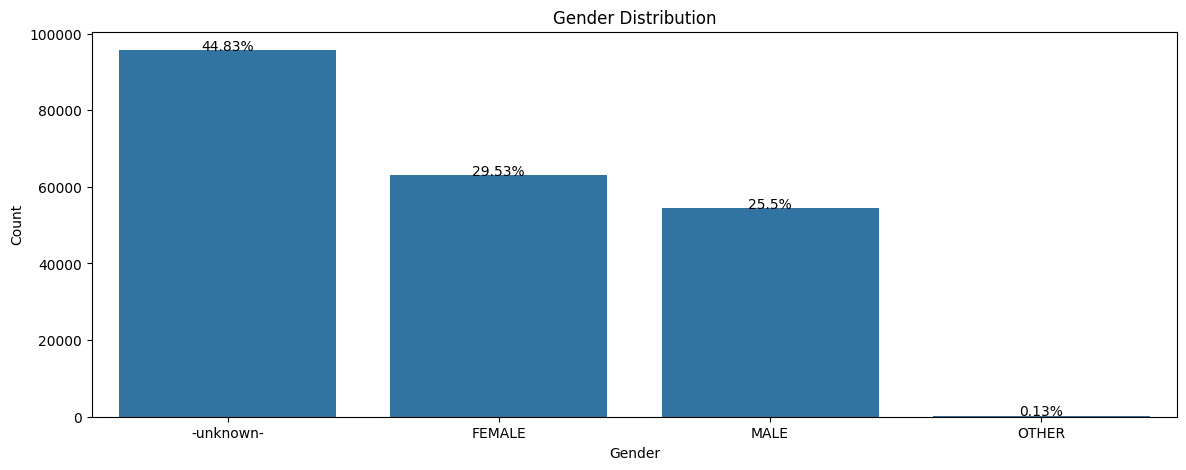

In [6]:
plt.figure(figsize=(14,5))
sns.countplot(x='gender', data=train, order=train['gender'].value_counts().index)

total = len(train)
for i, count in enumerate(train['gender'].value_counts()):
    percent = f"{round((count / total) * 100, 2)}%"
    plt.text(i, count, percent, ha='center')

plt.xlabel('Gender')
plt.ylabel('Count')
plt.title('Gender Distribution')
plt.show()

`Note -> majority of users dont disclosed their gender (44.83%) unknown`  

* Age

In [8]:
train['age'].isna().sum()

np.int64(87990)

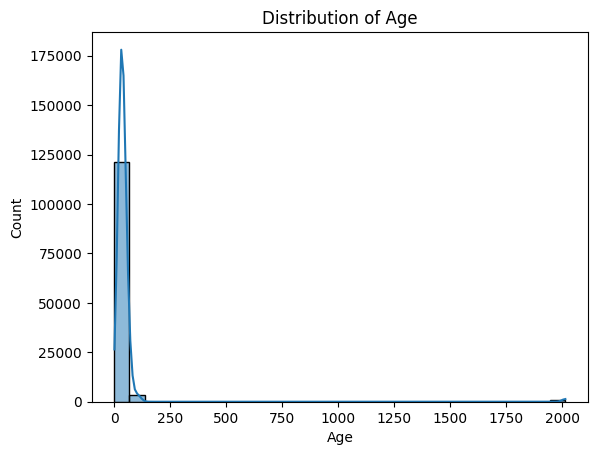

In [9]:
sns.histplot(train['age'], bins=30, kde=True)
plt.title('Distribution of Age')
plt.xlabel('Age')
plt.ylabel('Count')
plt.show()

`Note -> Age has very high outliers .` 

In [10]:
train['age'].describe()

count    125461.000000
mean         49.668335
std         155.666612
min           1.000000
25%          28.000000
50%          34.000000
75%          43.000000
max        2014.000000
Name: age, dtype: float64

`There are outliers in the minimum value (1) and in the maximum value  (2014).`

In [21]:
train['age'].value_counts(dropna=False).sort_values()

age
1935.0        1
1925.0        1
1927.0        1
132.0         1
1942.0        1
          ...  
28.0       5939
29.0       5963
31.0       6016
30.0       6124
NaN       87990
Name: count, Length: 128, dtype: int64

In [40]:
outliers_indexes = train[(train['age'] > 117) & (train['age'] < 1992)]['age'].index
outliers_indexes

Index([ 41046,  55474,  59537,  67223,  67610,  81999, 102044, 104695, 114377,
       114599, 118621, 144698, 145422, 156511, 157181, 157318, 160781, 180961,
       180995, 184424, 189661, 190142, 190565, 194056, 196558, 197386, 198888,
       206249, 208819, 211496],
      dtype='int64')

`check if age is between 117 and 1992. If true, i will substract that age value from the year of account 
    creation to get the exact age of the user on the year he created the account`

* date first booking 

In [43]:
train['date_first_booking'].isna().sum()/len(train)

np.float64(0.5834734904029496)

`for the test users anyway this field is completely empty & To prevent target leakage ` 
i will drop it 

* signup method 

In [46]:
train['signup_method'].value_counts()


signup_method
basic       152897
facebook     60008
google         546
Name: count, dtype: int64

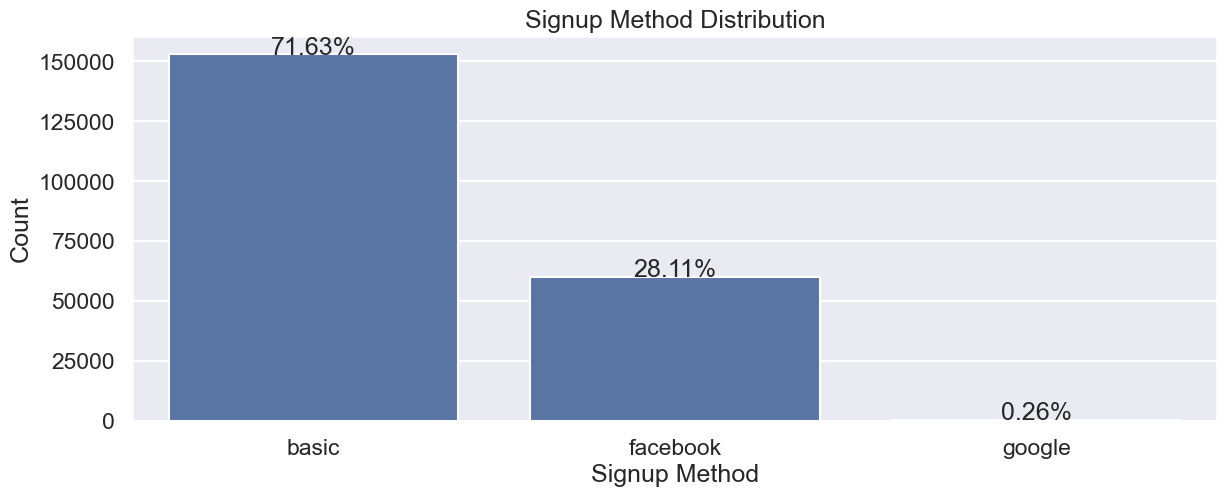

In [47]:
plt.figure(figsize=(14,5))
sns.countplot(x='signup_method', data=train, order=train['signup_method'].value_counts().index)

total = len(train)
for i, count in enumerate(train['signup_method'].value_counts()):
    percent = f"{round((count / total) * 100, 2)}%"
    plt.text(i, count, percent, ha='center')

plt.xlabel('Signup Method')
plt.ylabel('Count')
plt.title('Signup Method Distribution')
plt.show()

`Majority of the users (71.63%) used the basic method to create an account`

* Language

In [48]:
train['language'].value_counts()

language
en    206314
zh      1632
fr      1172
es       915
ko       747
de       732
it       514
ru       389
pt       240
ja       225
sv       122
nl        97
tr        64
da        58
pl        54
cs        32
no        30
el        24
th        24
id        22
hu        18
fi        14
ca         5
is         5
hr         2
Name: count, dtype: int64

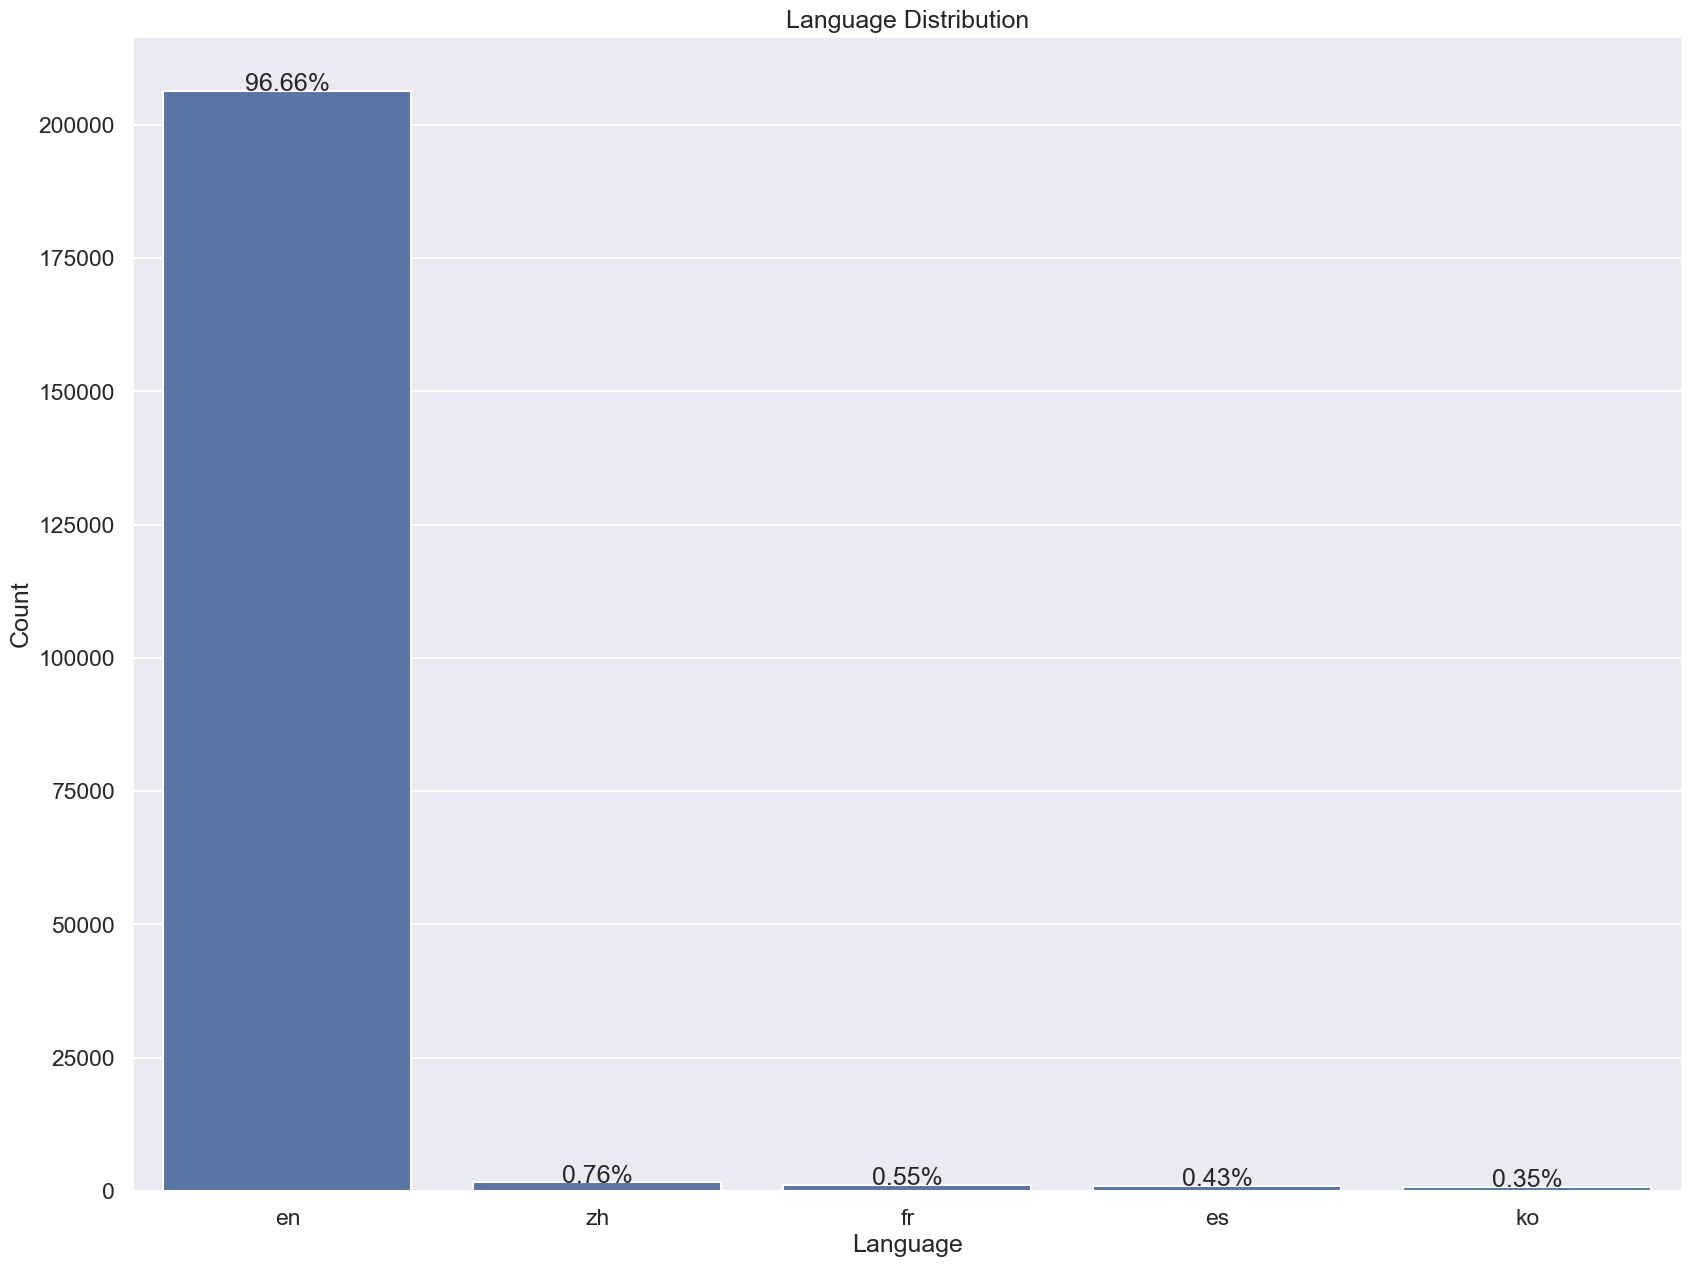

In [55]:
plt.figure(figsize=(20,15))
sns.countplot(x='language', data=train, order=train['language'].value_counts().head(5).index)

total = len(train)
for i, count in enumerate(train['language'].value_counts().head(5)):
    percent = f"{round((count / total) * 100, 2)}%"
    plt.text(i, count, percent, ha='center')

plt.xlabel('Language')
plt.ylabel('Count')
plt.title('Language Distribution')
plt.show()

`Majority of users (96.66%) have english`

* Affiliate provider

In [56]:
train['affiliate_provider'].value_counts()

affiliate_provider
direct                 137426
google                  51693
other                   12549
craigslist               3471
bing                     2328
facebook                 2273
vast                      829
padmapper                 768
facebook-open-graph       545
yahoo                     496
gsp                       453
meetup                    347
email-marketing           166
naver                      52
baidu                      29
yandex                     17
wayn                        8
daum                        1
Name: count, dtype: int64

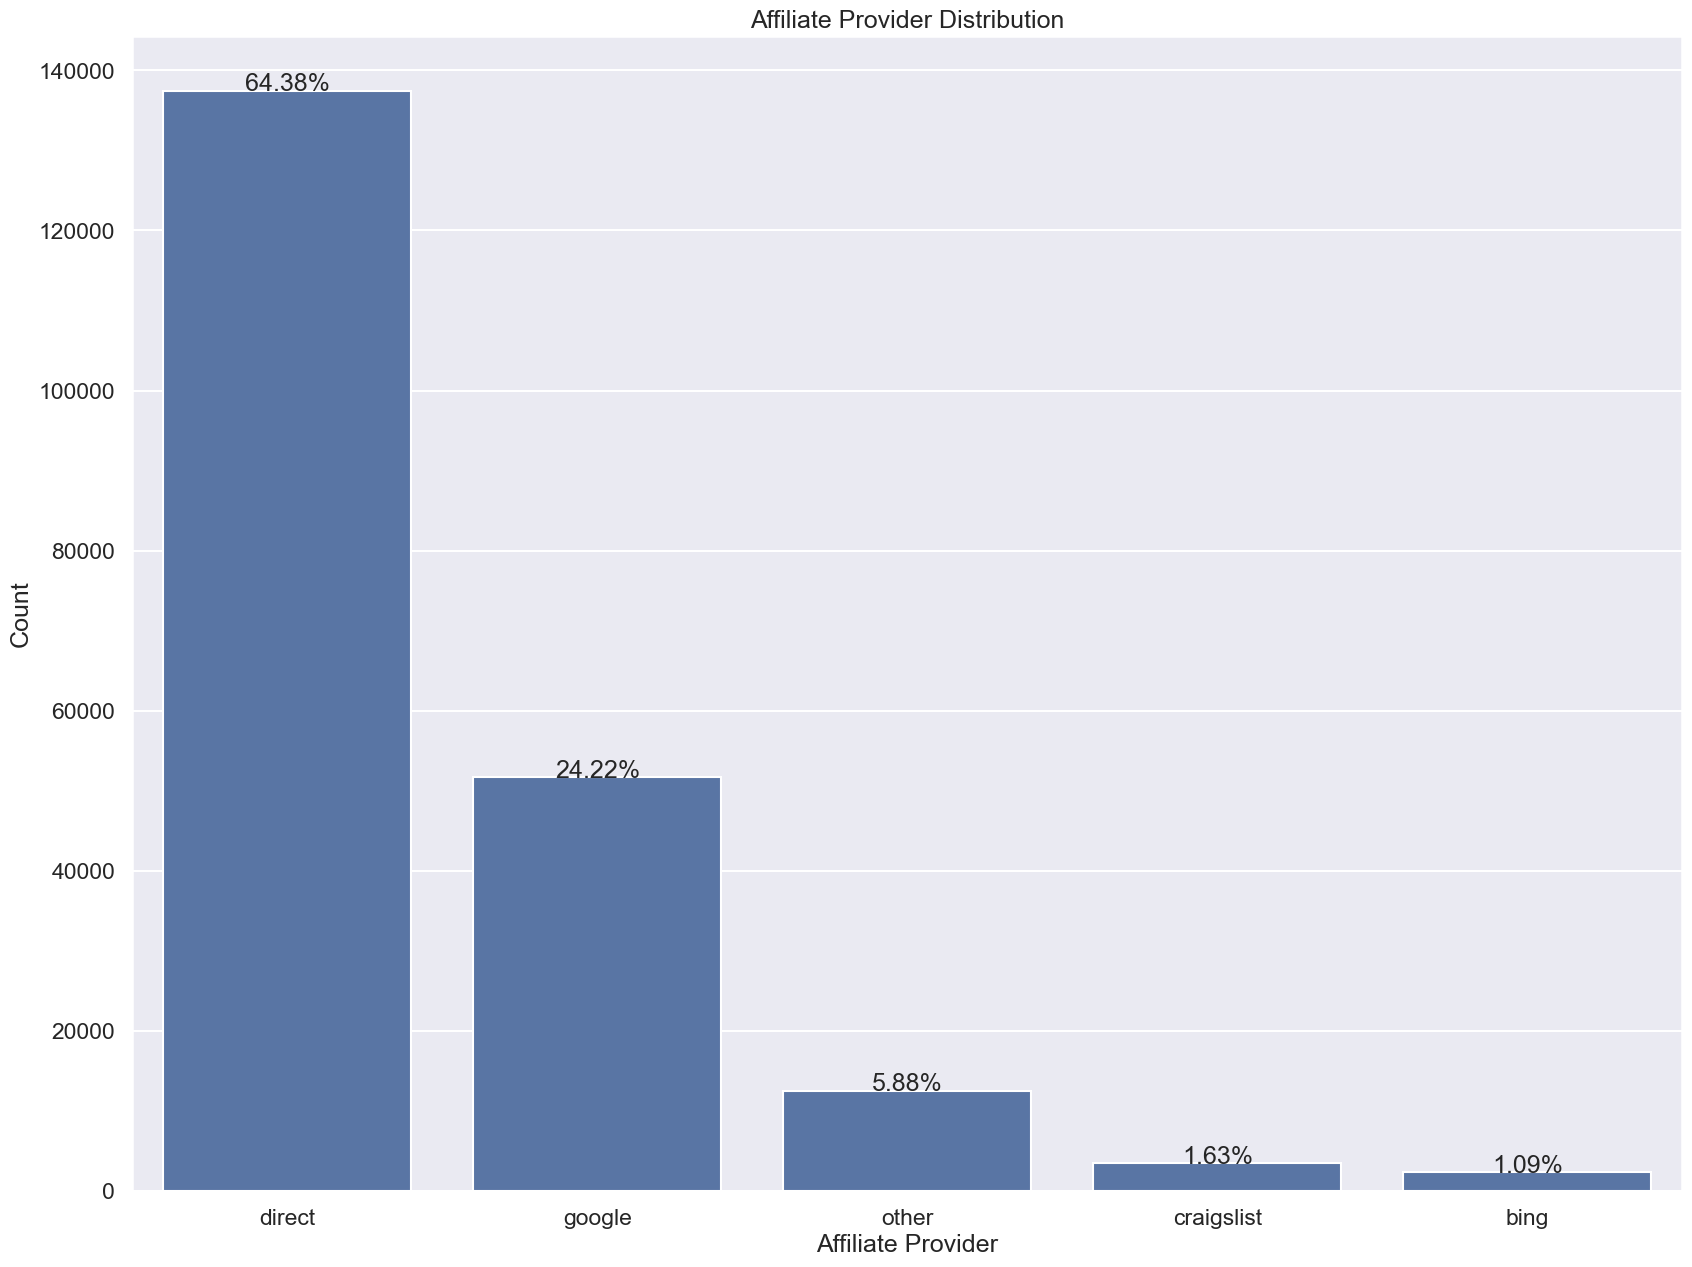

In [ ]:
plt.figure(figsize=(20,15))
sns.countplot(x='affiliate_provider', data=train, order=train['affiliate_provider'].value_counts().head(5).index)

total = len(train)
for i, count in enumerate(train['affiliate_provider'].value_counts().head(5)):
    percent = f"{round((count / total) * 100, 2)}%"
    plt.text(i, count, percent, ha='center')

plt.xlabel('Affiliate Provider')
plt.ylabel('Count')
plt.title('Affiliate Provider Distribution')
plt.show()

`A majority of the accounts (64.38%) are through 'dtrect' channel. & 'google' is also an important channel as it managed to reach a (24.22%) of accounts.` 

* Affiliate Channel 

In [58]:
train['affiliate_channel'].value_counts()

affiliate_channel
direct           137727
sem-brand         26045
sem-non-brand     18844
other              8961
seo                8663
api                8167
content            3948
remarketing        1096
Name: count, dtype: int64

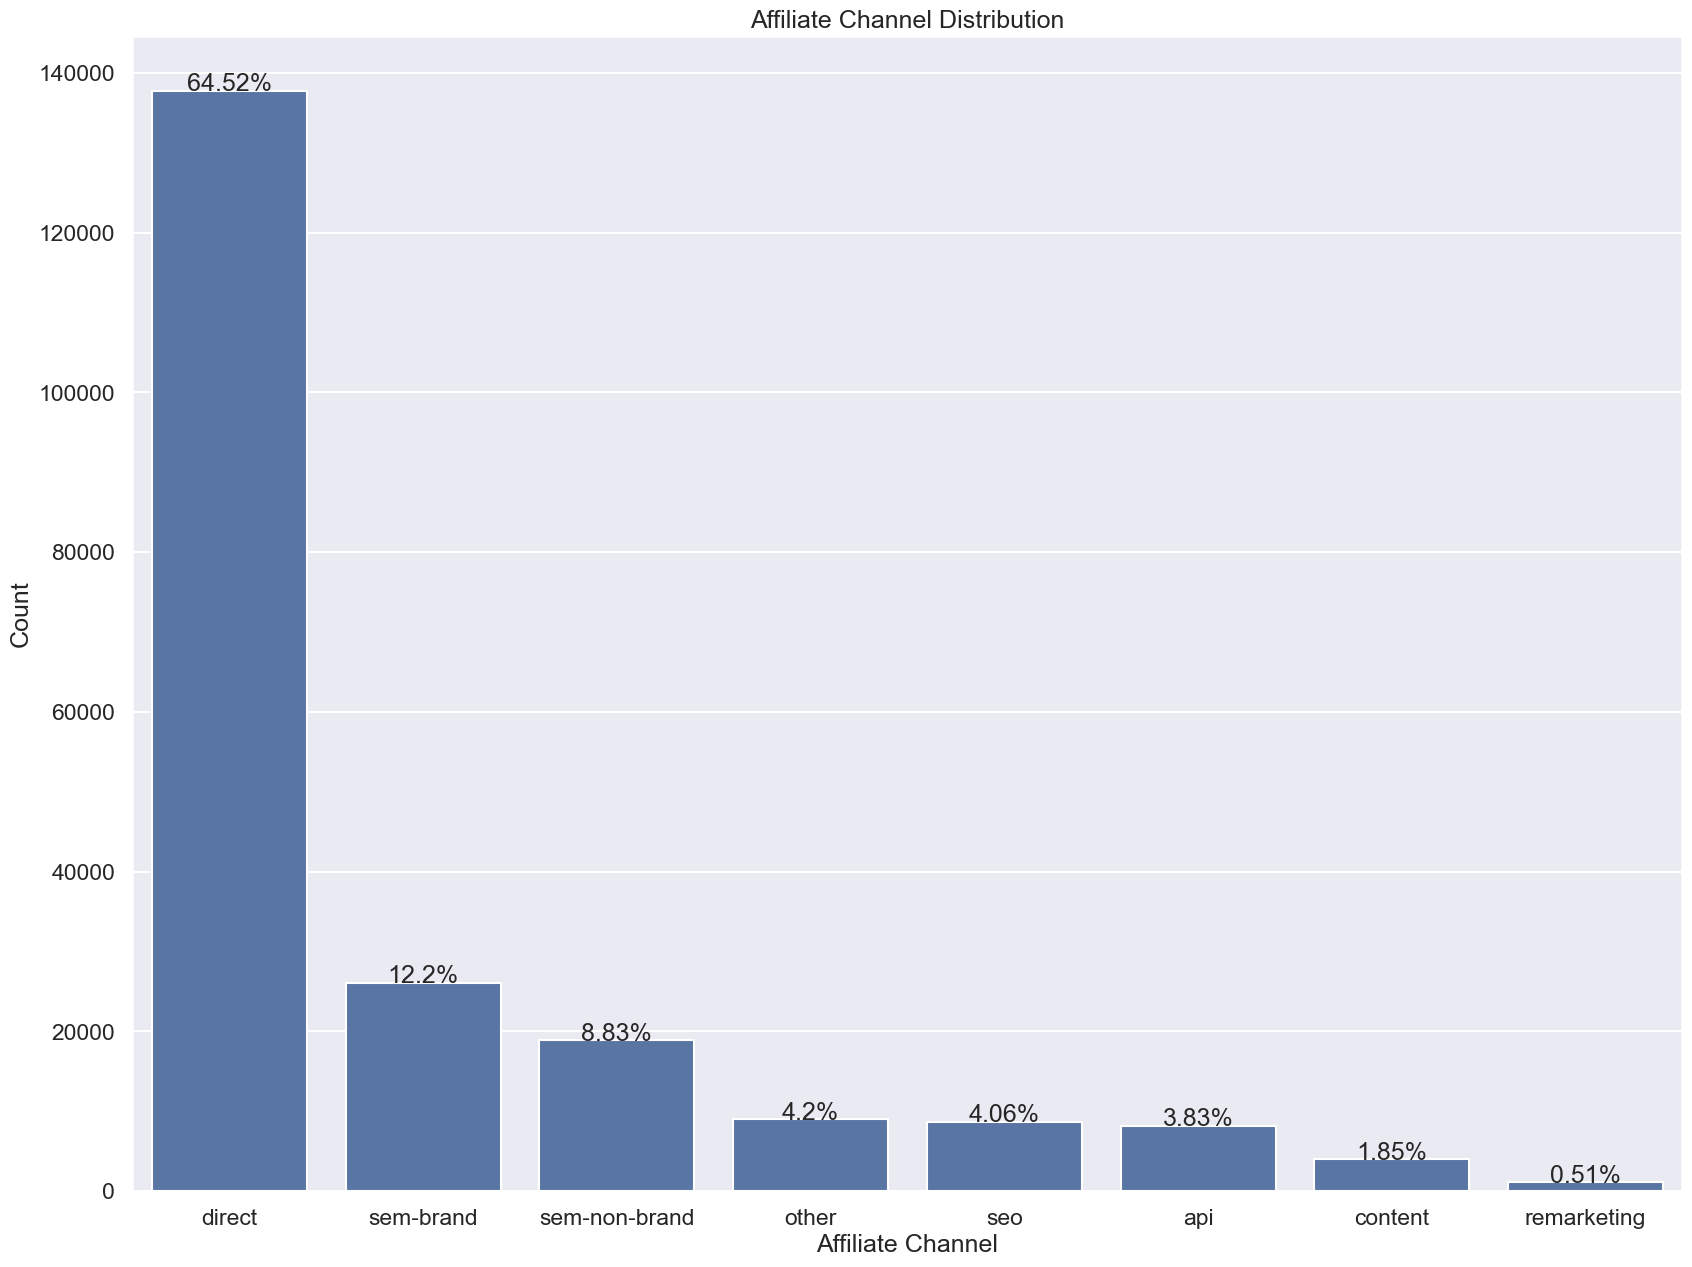

In [59]:
plt.figure(figsize=(20,15))
sns.countplot(x='affiliate_channel', data=train, order=train['affiliate_channel'].value_counts().index)

total = len(train)
for i, count in enumerate(train['affiliate_channel'].value_counts()):
    percent = f"{round((count / total) * 100, 2)}%"
    plt.text(i, count, percent, ha='center')

plt.xlabel('Affiliate Channel')
plt.ylabel('Count')
plt.title('Affiliate Channel Distribution')
plt.show()

**direct** is the most useful because it reached majority of the users (64.52%). and the second best one is 'sem-brand'

**content** and **remarketing** have reached a very small percentage of users -> these not useful for this app .

* First Affiliate Tracked 

In [60]:
train['first_affiliate_tracked'].value_counts(dropna=False)

first_affiliate_tracked
untracked        109232
linked            46287
omg               43982
tracked-other      6156
NaN                6065
product            1556
marketing           139
local ops            34
Name: count, dtype: int64

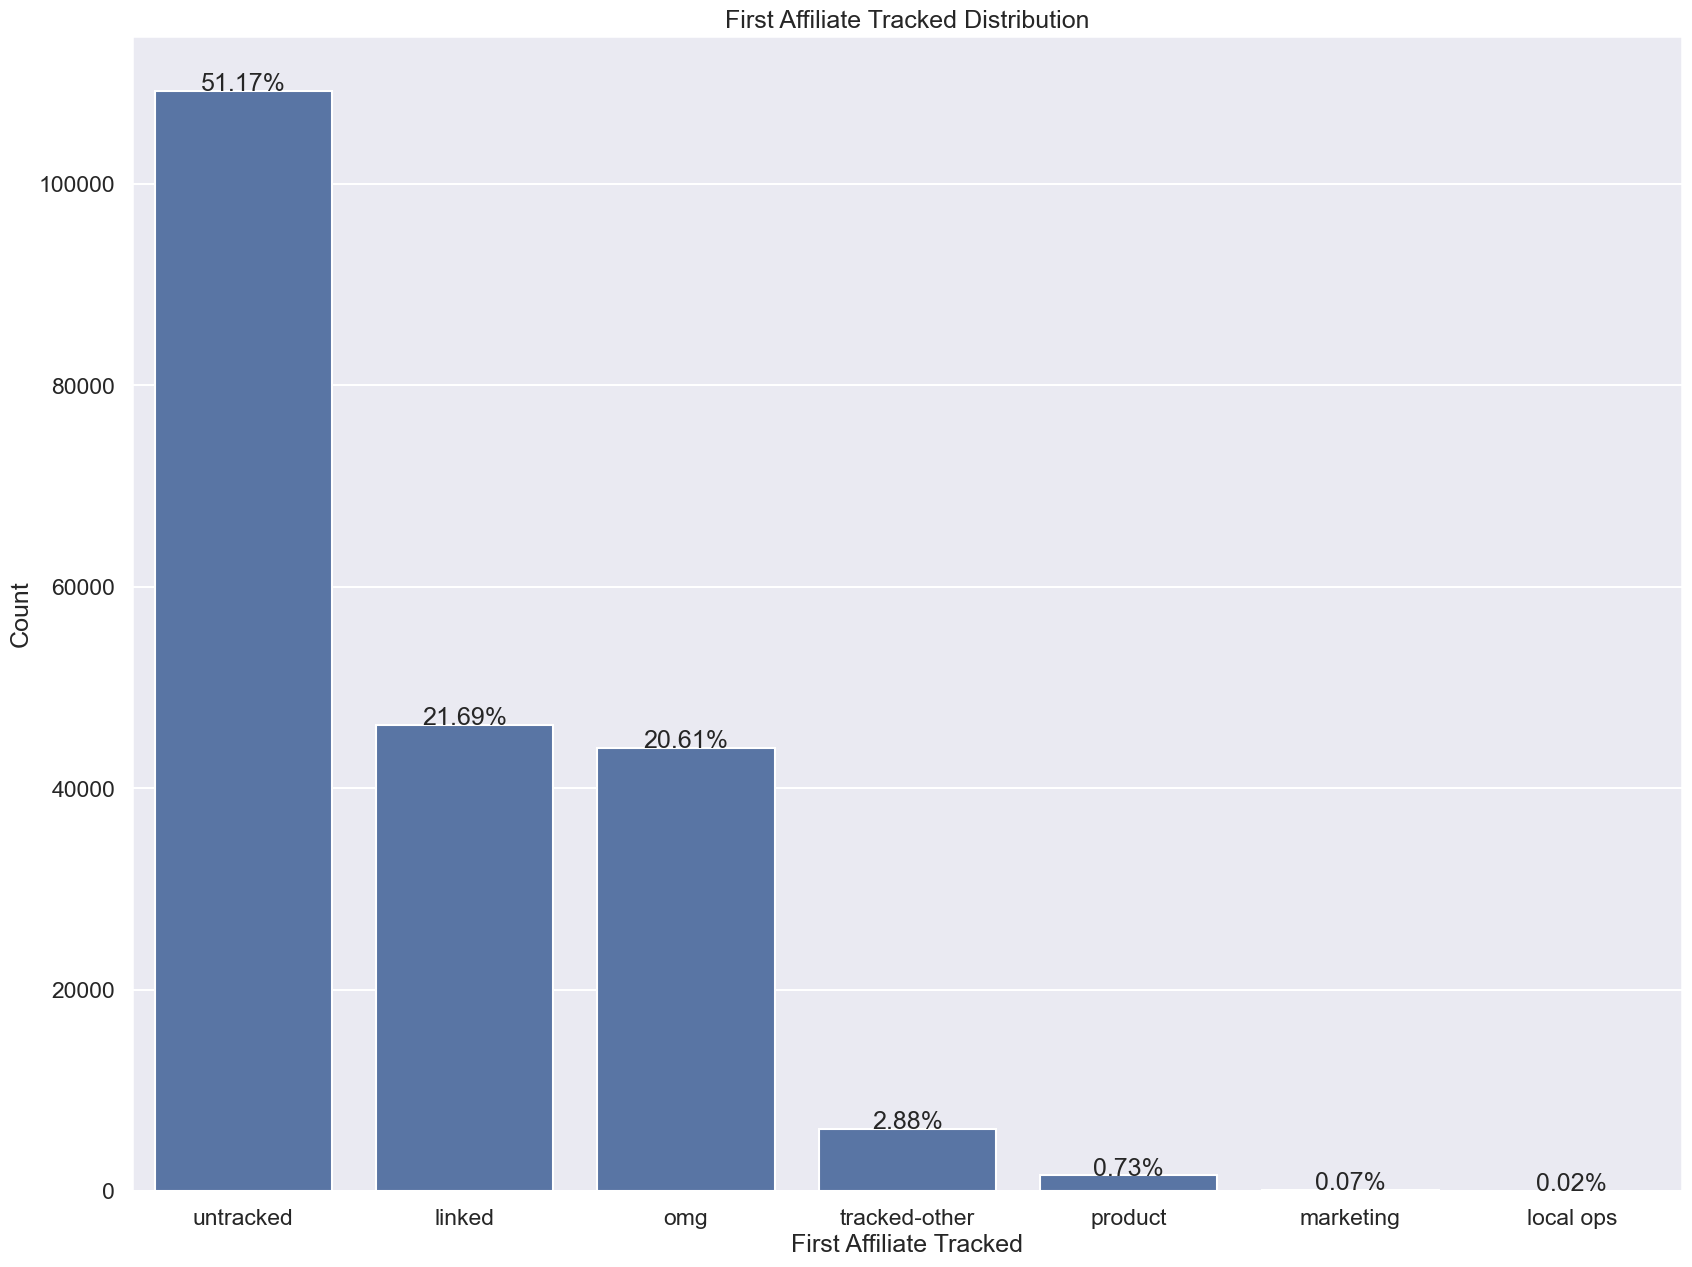

In [61]:
plt.figure(figsize=(20,15))
sns.countplot(x='first_affiliate_tracked', data=train, order=train['first_affiliate_tracked'].value_counts().index)

total = len(train)
for i, count in enumerate(train['first_affiliate_tracked'].value_counts()):
    percent = f"{round((count / total) * 100, 2)}%"
    plt.text(i, count, percent, ha='center')

plt.xlabel('First Affiliate Tracked')
plt.ylabel('Count')
plt.title('First Affiliate Tracked Distribution')
plt.show()

the best marketing channel that users sued it is **untracked** not known 

**marketing** and **local ops** are not useful channels -> drop it to save cost 

In [63]:
train.head()

,id,date_account_created,timestamp_first_active,date_first_booking,gender,age,signup_method,signup_flow,language,affiliate_channel,affiliate_provider,first_affiliate_tracked,signup_app,first_device_type,first_browser,country_destination
0,gxn3p5htnn,2010-06-28,20090319043255,NaN,-unknown-,NaN,facebook,0,en,direct,direct,untracked,Web,Mac Desktop,Chrome,NDF
1,820tgsjxq7,2011-05-25,20090523174809,NaN,MALE,38.0,facebook,0,en,seo,google,untracked,Web,Mac Desktop,Chrome,NDF
2,4ft3gnwmtx,2010-09-28,20090609231247,2010-08-02,FEMALE,56.0,basic,3,en,direct,direct,untracked,Web,Windows Desktop,IE,US
3,bjjt8pjhuk,2011-12-05,20091031060129,2012-09-08,FEMALE,42.0,facebook,0,en,direct,direct,untracked,Web,Mac Desktop,Firefox,other
4,87mebub9p4,2010-09-14,20091208061105,2010-02-18,-unknown-,41.0,basic,0,en,direct,direct,untracked,Web,Mac Desktop,Chrome,US


* Signup App

In [64]:
train['signup_app'].value_counts(dropna=False)


signup_app
Web        182717
iOS         19019
Moweb        6261
Android      5454
Name: count, dtype: int64

`the most used app is web`

* First_device_type 

In [66]:
train['first_device_type'].isna().sum()

np.int64(0)

In [65]:
train['first_device_type'].value_counts(dropna=False)

first_device_type
Mac Desktop           89600
Windows Desktop       72716
iPhone                20759
iPad                  14339
Other/Unknown         10667
Android Phone          2803
Android Tablet         1292
Desktop (Other)        1199
SmartPhone (Other)       76
Name: count, dtype: int64

`Note -> Apple devices more popular than Android and i will categories them into groups` 

* First Browser 

In [67]:
train['first_browser'].value_counts(dropna=False)   

first_browser
Chrome                  63845
Safari                  45169
Firefox                 33655
-unknown-               27266
IE                      21068
Mobile Safari           19274
Chrome Mobile            1270
Android Browser           851
AOL Explorer              245
Opera                     188
Silk                      124
Chromium                   73
BlackBerry Browser         53
Maxthon                    46
IE Mobile                  36
Apple Mail                 36
Sogou Explorer             33
Mobile Firefox             30
RockMelt                   24
SiteKiosk                  24
Iron                       17
IceWeasel                  13
Pale Moon                  12
SeaMonkey                  11
CometBird                  11
Yandex.Browser             11
Camino                      9
TenFourFox                  8
CoolNovo                    6
wOSBrowser                  6
Opera Mini                  4
Avant Browser               4
Mozilla                   

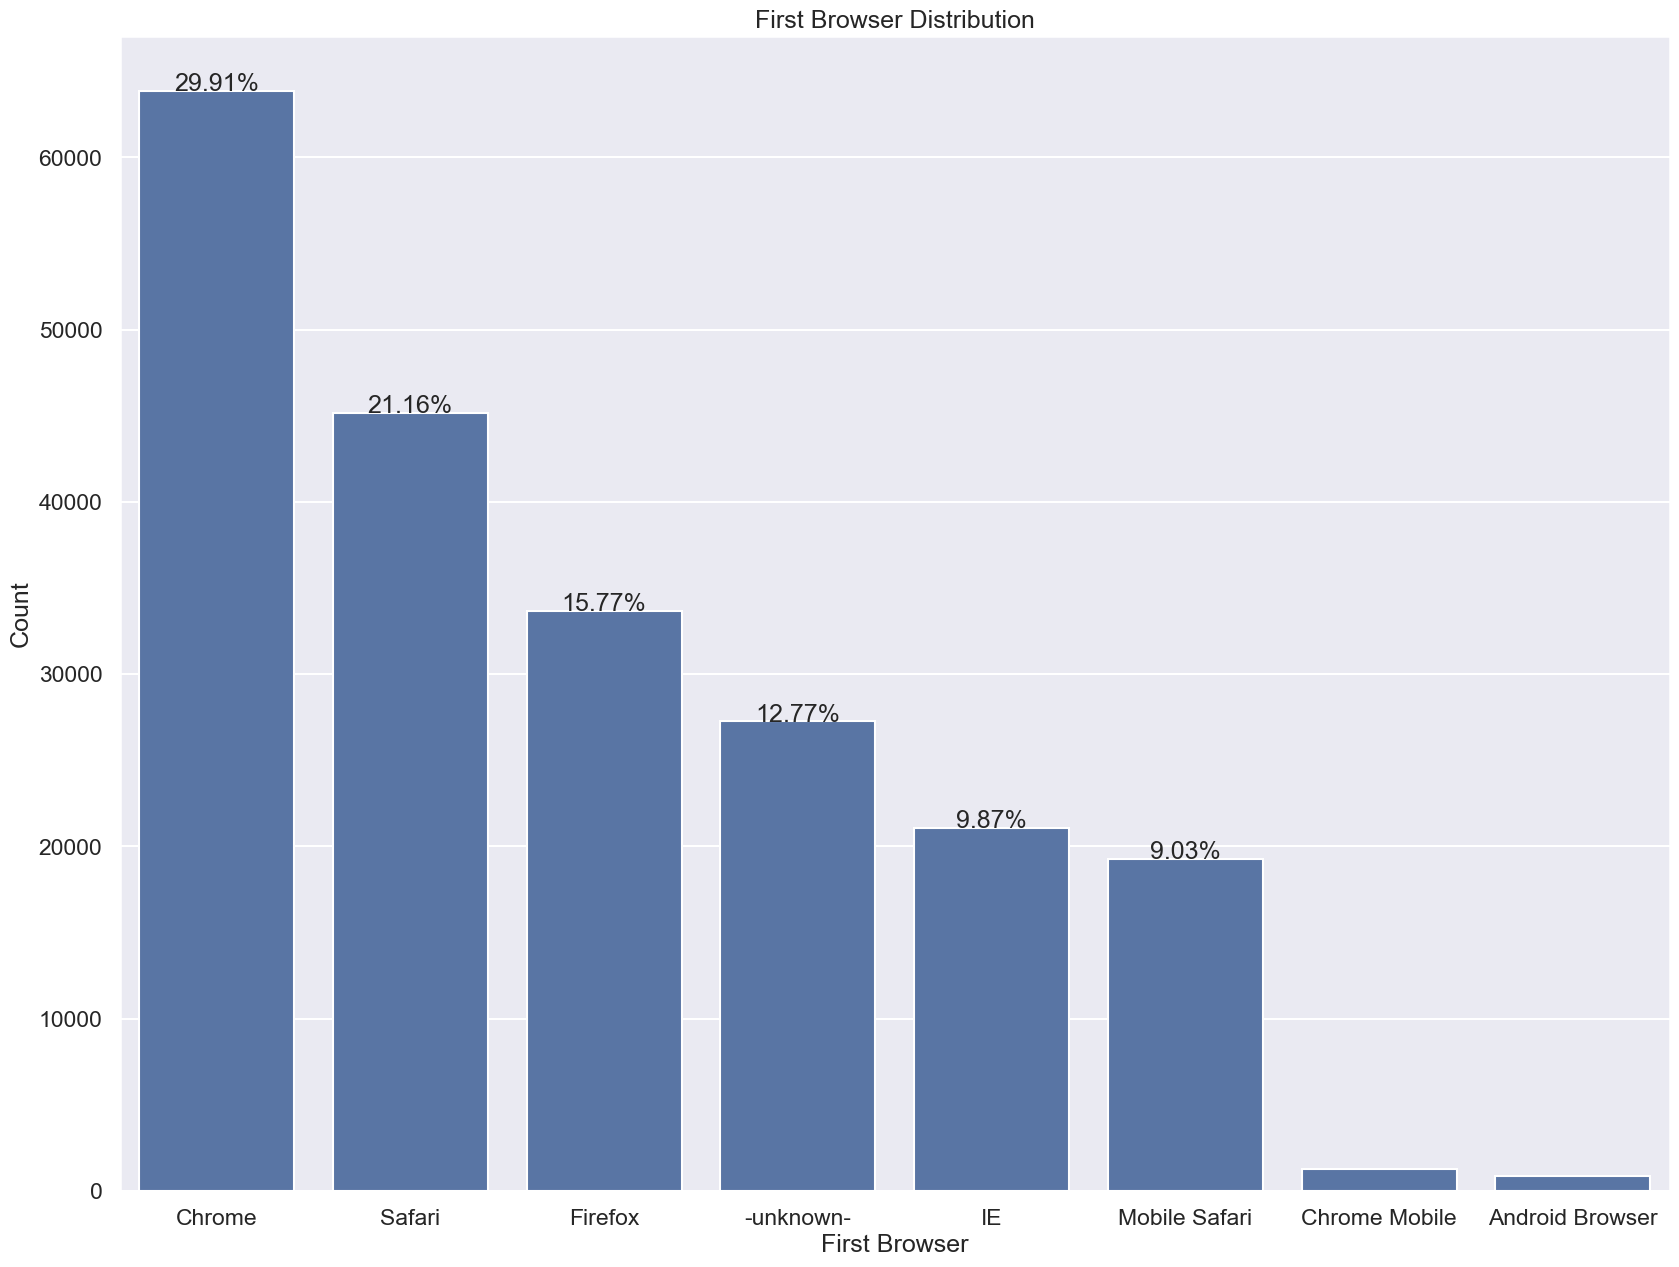

In [ ]:
plt.figure(figsize=(20,15))
sns.countplot(x='first_browser', data=train, order=train['first_browser'].value_counts().head(8).index)

total = len(train)
for i, count in enumerate(train['first_browser'].value_counts().head(6)):
    percent = f"{round((count / total) * 100, 2)}%"
    plt.text(i, count, percent, ha='center')

plt.xlabel('First Browser')
plt.ylabel('Count')
plt.title('First Browser Distribution')
plt.show()

1. (12.77%) from customer is unknown what first browser they used .
2. customers prefered chrome more than safari and firefox   

In [71]:
train.head()

,id,date_account_created,timestamp_first_active,date_first_booking,gender,age,signup_method,signup_flow,language,affiliate_channel,affiliate_provider,first_affiliate_tracked,signup_app,first_device_type,first_browser,country_destination
0,gxn3p5htnn,2010-06-28,20090319043255,NaN,-unknown-,NaN,facebook,0,en,direct,direct,untracked,Web,Mac Desktop,Chrome,NDF
1,820tgsjxq7,2011-05-25,20090523174809,NaN,MALE,38.0,facebook,0,en,seo,google,untracked,Web,Mac Desktop,Chrome,NDF
2,4ft3gnwmtx,2010-09-28,20090609231247,2010-08-02,FEMALE,56.0,basic,3,en,direct,direct,untracked,Web,Windows Desktop,IE,US
3,bjjt8pjhuk,2011-12-05,20091031060129,2012-09-08,FEMALE,42.0,facebook,0,en,direct,direct,untracked,Web,Mac Desktop,Firefox,other
4,87mebub9p4,2010-09-14,20091208061105,2010-02-18,-unknown-,41.0,basic,0,en,direct,direct,untracked,Web,Mac Desktop,Chrome,US


* Country Destination (Target) 

In [72]:
train['country_destination'].value_counts()

country_destination
NDF      124543
US        62376
other     10094
FR         5023
IT         2835
GB         2324
ES         2249
CA         1428
DE         1061
NL          762
AU          539
PT          217
Name: count, dtype: int64

C:\Users\El-Wattaneya\AppData\Local\Temp\ipykernel_16896\2969495451.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x='country_destination', data=train, order=train['country_destination'].value_counts().index , palette='rocket')


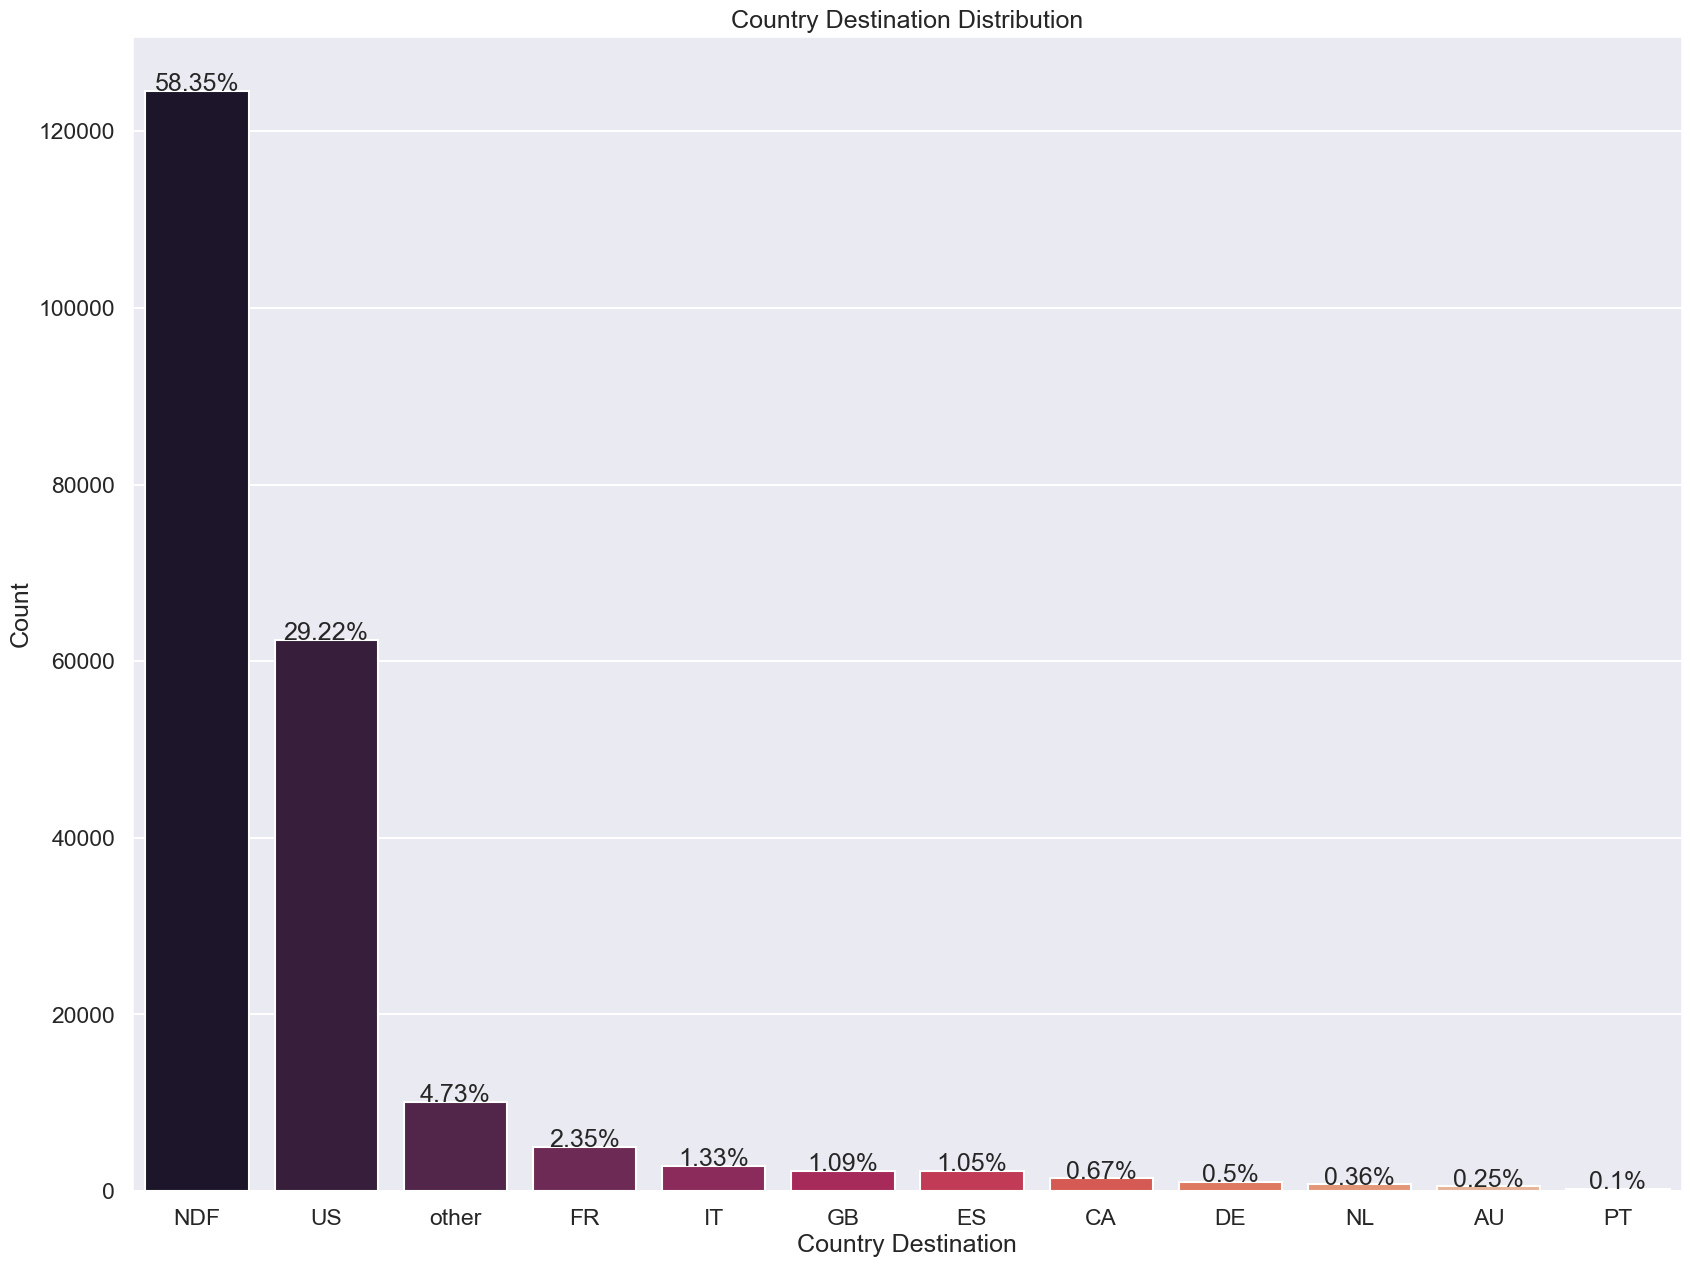

In [77]:
plt.figure(figsize=(20,15))
sns.countplot(x='country_destination', data=train, order=train['country_destination'].value_counts().index , palette='rocket')

total = len(train)
for i, count in enumerate(train['country_destination'].value_counts()):
    percent = f"{round((count / total) * 100, 2)}%"
    plt.text(i, count, percent, ha='center')

plt.xlabel('Country Destination')
plt.ylabel('Count')
plt.title('Country Destination Distribution')
plt.show()

`high Imbalance in data to NDF` -> i will do oversampling using (class weight or SMOTE to balance the data) 

1. (58.35%) of customers not mad a booking . 
2. About the customers they book -> large of customers booked for **US** 
3. About another countries  -> **France** has (2.35%) of customers . 
   

### Bivariate Analysis 

* Users sign up methods with target

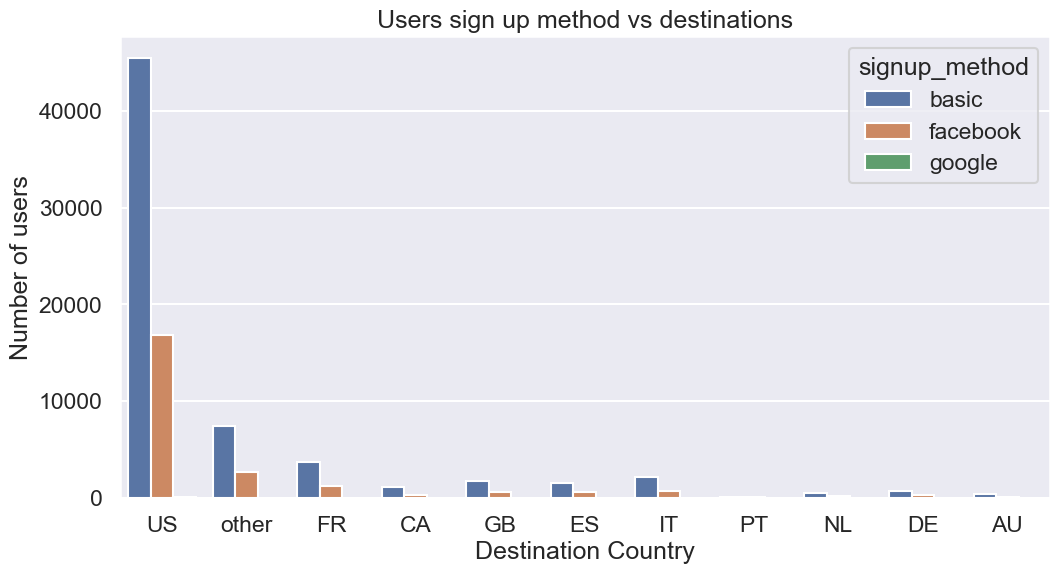

In [97]:
plt.figure(figsize=(12,6))
sns.countplot(x= train[train['country_destination'] != 'NDF']['country_destination'], hue = train[train['country_destination'] != 'NDF']['signup_method'])
plt.xlabel('Destination Country')
plt.ylabel('Number of users')
plt.title('Users sign up method vs destinations')
plt.show()

`Among the users who made atleast one booking, most of them used basic method (email & password) to signup`

* first device type target

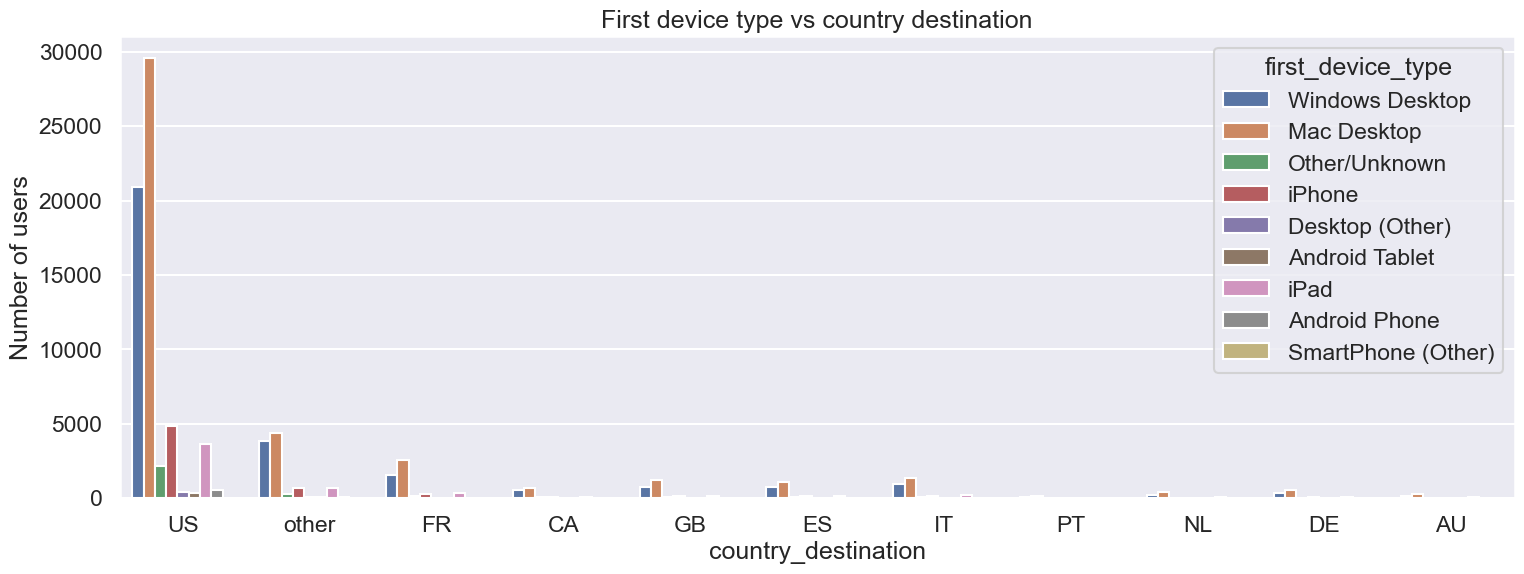

In [98]:
plt.figure(figsize=(18,6))
sns.countplot(x=train[train['country_destination']!='NDF']['country_destination'], hue=train[train['country_destination']!='NDF']['first_device_type'])
plt.ylabel('Number of users')
plt.title('First device type vs country destination')
plt.show()

**mac desktop** is the favourite device that customers use it to booking in this website. and is highest in **US**    

## Sessions EDA 

In [154]:
sessions = pd.read_csv("data/sessions.csv")
sessions.head()

,user_id,action,action_type,action_detail,device_type,secs_elapsed
0,d1mm9tcy42,lookup,NaN,NaN,Windows Desktop,319.0
1,d1mm9tcy42,search_results,click,view_search_results,Windows Desktop,67753.0
2,d1mm9tcy42,lookup,NaN,NaN,Windows Desktop,301.0
3,d1mm9tcy42,search_results,click,view_search_results,Windows Desktop,22141.0
4,d1mm9tcy42,lookup,NaN,NaN,Windows Desktop,435.0


In [155]:
sessions.info()

<class 'pandas.DataFrame'>
RangeIndex: 10567737 entries, 0 to 10567736
Data columns (total 6 columns):
 #   Column         Dtype  
---  ------         -----  
 0   user_id        str    
 1   action         str    
 2   action_type    str    
 3   action_detail  str    
 4   device_type    str    
 5   secs_elapsed   float64
dtypes: float64(1), str(5)
memory usage: 483.8 MB


* User ID 

In [156]:
sessions.isna().sum()

user_id            34496
action             79626
action_type      1126204
action_detail    1126204
device_type            0
secs_elapsed      136031
dtype: int64

In [157]:
sessions['user_id'].nunique() 

135483

In [158]:
sessions['user_id'].isnull().sum()

np.int64(34496)

In [159]:
sessions = sessions.dropna(subset=['user_id']) 

In [160]:
sessions.isna().sum() 

user_id                0
action             79480
action_type      1122957
action_detail    1122957
device_type            0
secs_elapsed      135483
dtype: int64

these **Nans** happens when user: 

1. Browse the site in Incognito Mode.
2. Uses ad-blocker that breaks the tracking .

* User Actions ( `action & action_type & action_details`)

In [167]:
sessions['action'].value_counts().head(10)

action
show                     2758985
index                     841071
search_results            723124
personalize               704782
search                    533833
ajax_refresh_subtotal     486414
similar_listings          363423
update                    362708
social_connections        337764
reviews                   319318
Name: count, dtype: int64

In [ ]:
sessions['action'] = sessions['action'].fillna('unknown')

In [172]:
sessions['action'].isna().sum()

np.int64(0)

`Note -> missing action usually represents a "silent" event`

In [173]:
sessions['action_type'].value_counts()

action_type
view                3549375
data                2096655
click               1990058
-unknown-           1028251
submit               620063
message_post          86925
partner_callback      19053
booking_request       18762
modify                 1138
booking_response          4
Name: count, dtype: int64

In [174]:
sessions['action_type'] = sessions['action_type'].fillna('-unknown-')

In [181]:
sessions['action_type'] = sessions['action_type'].replace('-unknown-', 'unknown')

In [182]:
sessions['action_type'].value_counts()

action_type
view                3549375
unknown             2151208
data                2096655
click               1990058
submit               620063
message_post          86925
partner_callback      19053
booking_request       18762
modify                 1138
booking_response          4
Name: count, dtype: int64

In [176]:
sessions['action_detail'].value_counts().head(10)

action_detail
view_search_results            1771026
p3                             1371626
-unknown-                      1028222
wishlist_content_update         704782
user_profile                    654626
change_trip_characteristics     486414
similar_listings                363423
user_social_connections         335577
listing_reviews                 267991
update_listing                  267776
Name: count, dtype: int64

In [177]:
sessions['action_detail'] = sessions['action_detail'].fillna('-unknown-')

In [183]:
sessions['action_detail'] = sessions['action_detail'].replace('-unknown-', 'unknown')

In [185]:
sessions['action_detail'].value_counts().head(10)

action_detail
unknown                        2151179
view_search_results            1771026
p3                             1371626
wishlist_content_update         704782
user_profile                    654626
change_trip_characteristics     486414
similar_listings                363423
user_social_connections         335577
listing_reviews                 267991
update_listing                  267776
Name: count, dtype: int64

In [184]:
sessions.isna().sum()

user_id               0
action                0
action_type           0
action_detail         0
device_type           0
secs_elapsed     135483
dtype: int64

* Device Type 

In [186]:
sessions['device_type'].value_counts()

device_type
Mac Desktop                         3585886
Windows Desktop                     2648521
iPhone                              2096749
Android Phone                        835991
iPad Tablet                          681836
Android App Unknown Phone/Tablet     272820
-unknown-                            210059
Tablet                               139859
Linux Desktop                         27968
Chromebook                            22272
iPodtouch                              8186
Windows Phone                          2047
Blackberry                              979
Opera Phone                              68
Name: count, dtype: int64

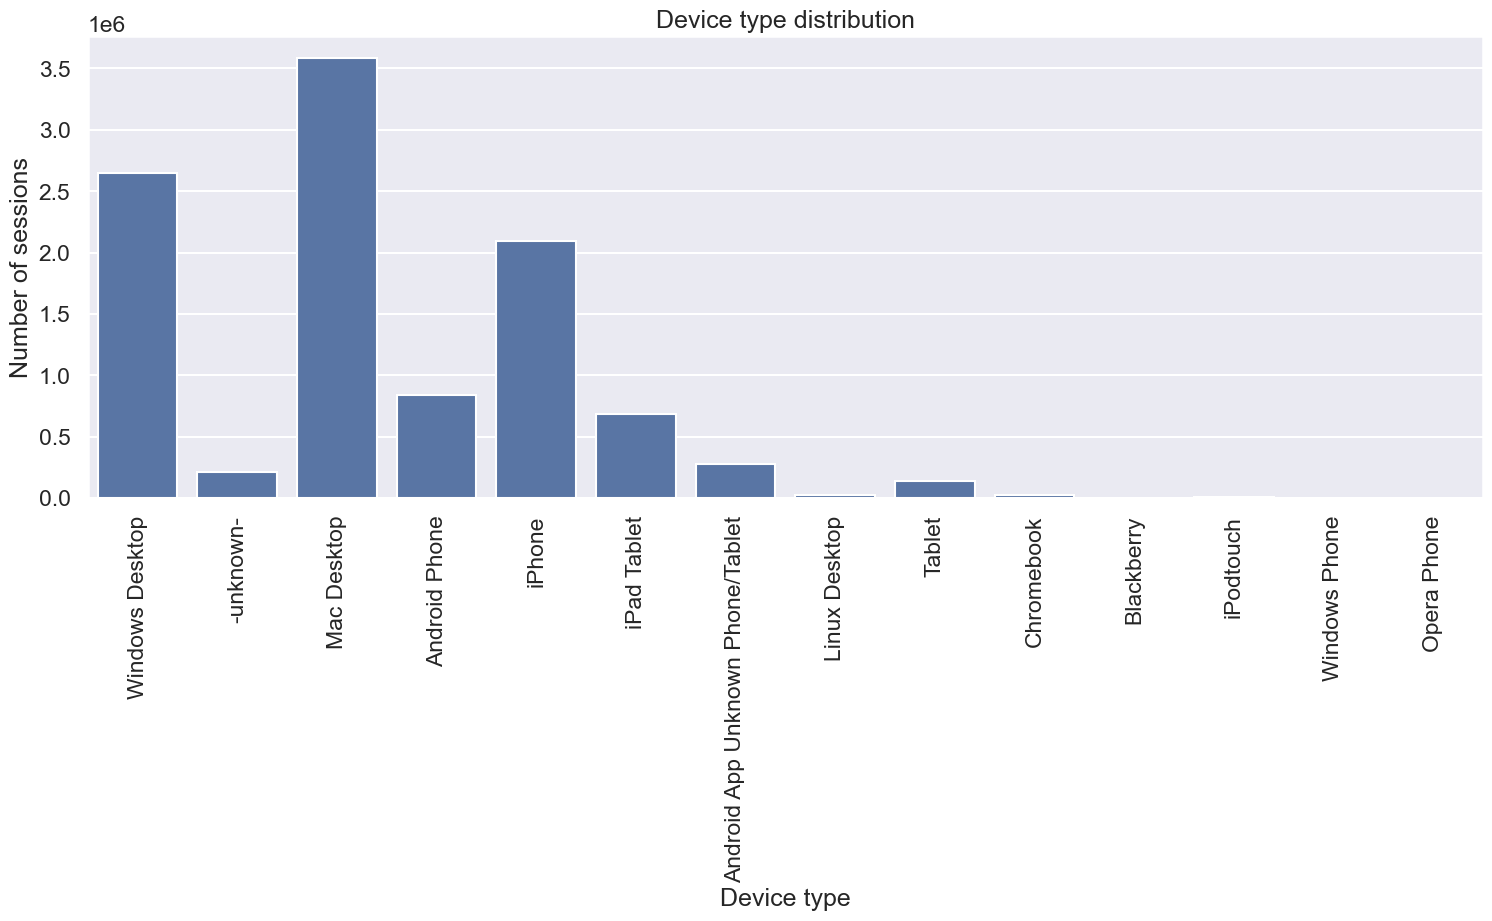

In [180]:
plt.figure(figsize=(18,6))
sns.countplot(x= sessions['device_type'])
plt.xlabel('Device type')
plt.ylabel('Number of sessions')
plt.title('Device type distribution')
plt.show()

As i discovered even earlier i explored the users data that the most popular device **Mac Desktop**.

* Secs_elapsed 

In [189]:
sessions['secs_elapsed'].isna().sum() 

np.int64(135483)

`But what happens on their very last click before they close the browser tab? The stopwatch starts, but it never stops because they left the website. The tracker logs the action, but leaves secs_elapsed as NaN.`

Sol -> fit it with 0 
mathematically represents that no additional time was tracked before the session ended, and it perfectly preserves the row so you can still count the action and the device.

In [190]:
sessions['secs_elapsed'] = sessions['secs_elapsed'].fillna(0)

In [191]:
sessions['secs_elapsed'].isna().sum() 

np.int64(0)